**Icha Meisya Kurnia (25031554047)**

**Putri Najwa Zuleyka Al Hasni (25031554076)**

In [ ]:
import warnings
warnings.filterwarnings(action='ignore')

import re
import string
import requests
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
url = "https://api.spaceflightnewsapi.net/v4/articles/"
response = requests.get(url)
data = response.json()

df = pd.DataFrame(data['results'])
df.rename(columns={'summary': 'text'}, inplace=True)
df.head()

,id,title,authors,url,image_url,news_site,text,published_at,updated_at,featured,launches,events
0,40077,European Lunar Rover Secures Spot Aboard Blue ...,"[{'name': 'European Spaceflight', 'socials': N...",https://europeanspaceflight.com/european-lunar...,https://europeanspaceflight.com/wp-content/upl...,European Spaceflight,Belgium’s Space Applications Services has secu...,2026-09-24T13:45:53Z,2026-09-24T13:50:09.677538Z,False,[],[]
1,40074,Starfish Space’s first Otter servicing vehicle...,"[{'name': 'Chris Bergin', 'socials': None}]",https://www.nasaspaceflight.com/2026/09/starfi...,https://www.nasaspaceflight.com/wp-content/upl...,NASASpaceflight,Starfish Space has confirmed that its first fu...,2026-09-24T13:00:13Z,2026-09-24T13:00:23.413519Z,False,[],[]
2,40075,New tests for rendezvous and docking interoper...,"[{'name': 'ESA', 'socials': None}]",https://www.esa.int/Enabling_Support/Space_Eng...,https://www.esa.int/var/esa/storage/images/esa...,ESA,"Currently, space missions are one-shot affairs...",2026-09-24T13:00:00Z,2026-09-24T13:20:20.214928Z,False,[],[]
3,40076,Win a trip to ESA to witness BepiColombo arriv...,"[{'name': 'ESA', 'socials': None}]",https://www.esa.int/Science_Exploration/Space_...,https://www.esa.int/var/esa/storage/images/esa...,ESA,Get ready to celebrate BepiColombo’s arrival a...,2026-09-24T13:00:00Z,2026-09-24T13:40:23.146507Z,False,[],[]
4,40073,Record participation in ESA’s Industry Space D...,"[{'name': 'ESA', 'socials': None}]",https://www.esa.int/About_Us/Business_with_ESA...,https://www.esa.int/var/esa/storage/images/esa...,ESA,"On 16–17 September, the European Space Agency ...",2026-09-24T07:05:00Z,2026-09-24T07:20:19.134672Z,False,[],[]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            10 non-null     int64 
 1   title         10 non-null     object
 2   authors       10 non-null     object
 3   url           10 non-null     object
 4   image_url     10 non-null     object
 5   news_site     10 non-null     object
 6   text          10 non-null     object
 7   published_at  10 non-null     object
 8   updated_at    10 non-null     object
 9   featured      10 non-null     bool  
 10  launches      10 non-null     object
 11  events        10 non-null     object
dtypes: bool(1), int64(1), object(10)
memory usage: 1022.0+ bytes


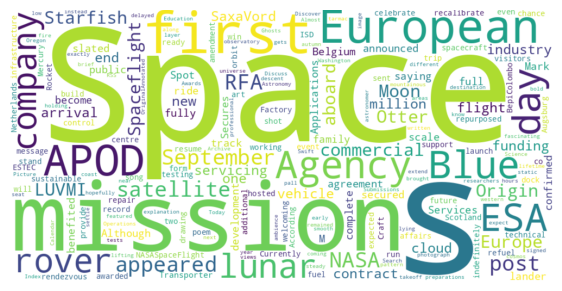

In [ ]:
text = ' '.join(df['text'].dropna().astype(str))

wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=5000).generate(text)

plt.figure(figsize=(7, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
def remove_html(text):
    html_pattern = re.compile('<.*?>')
    return html_pattern.sub(r'', str(text))

def remove_hashtag(text):
    return re.sub(r'#\w+', '', str(text))

def remove_rls(text):
    text = re.sub(r'https?\/\/\S+', '', str(text))
    text = re.sub(r'http\S+', '', str(text))
    text = re.sub(r'www\S+', '', str(text))
    text = re.sub(r'\S+@\S+', '', str(text))
    return text

def remove_punctuation_list(text):
    text = re.sub(r'[!"#$%&\'()*+,\-./:;<=>?@\[\]^_`{|}~]', ' ', str(text))
    text = re.sub(r'\s+', ' ', str(text)).strip()
    return text

wnl = WordNetLemmatizer()
def lemmatize_text(text):
    return " ".join([wnl.lemmatize(word) for word in str(text).split()])

sw = set(stopwords.words('english'))
def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in sw])

In [ ]:
df['rm_html'] = df['text'].apply(remove_html)
df[['text', 'rm_html']].head()

,text,rm_html
0,Belgium’s Space Applications Services has secu...,Belgium’s Space Applications Services has secu...
1,Starfish Space has confirmed that its first fu...,Starfish Space has confirmed that its first fu...
2,"Currently, space missions are one-shot affairs...","Currently, space missions are one-shot affairs..."
3,Get ready to celebrate BepiColombo’s arrival a...,Get ready to celebrate BepiColombo’s arrival a...
4,"On 16–17 September, the European Space Agency ...","On 16–17 September, the European Space Agency ..."


In [ ]:
df['rm_hashtag'] = df['rm_html'].apply(remove_hashtag)
df[['rm_html', 'rm_hashtag']].head()

,rm_html,rm_hashtag
0,Belgium’s Space Applications Services has secu...,Belgium’s Space Applications Services has secu...
1,Starfish Space has confirmed that its first fu...,Starfish Space has confirmed that its first fu...
2,"Currently, space missions are one-shot affairs...","Currently, space missions are one-shot affairs..."
3,Get ready to celebrate BepiColombo’s arrival a...,Get ready to celebrate BepiColombo’s arrival a...
4,"On 16–17 September, the European Space Agency ...","On 16–17 September, the European Space Agency ..."


In [ ]:
df['lower_case'] = df['rm_hashtag'].str.lower()
df[['rm_hashtag', 'lower_case']].head()

,rm_hashtag,lower_case
0,Belgium’s Space Applications Services has secu...,belgium’s space applications services has secu...
1,Starfish Space has confirmed that its first fu...,starfish space has confirmed that its first fu...
2,"Currently, space missions are one-shot affairs...","currently, space missions are one-shot affairs..."
3,Get ready to celebrate BepiColombo’s arrival a...,get ready to celebrate bepicolombo’s arrival a...
4,"On 16–17 September, the European Space Agency ...","on 16–17 september, the european space agency ..."


In [ ]:
df['rm_url'] = df['lower_case'].apply(remove_rls)
df[['lower_case', 'rm_url']].head()

,lower_case,rm_url
0,belgium’s space applications services has secu...,belgium’s space applications services has secu...
1,starfish space has confirmed that its first fu...,starfish space has confirmed that its first fu...
2,"currently, space missions are one-shot affairs...","currently, space missions are one-shot affairs..."
3,get ready to celebrate bepicolombo’s arrival a...,get ready to celebrate bepicolombo’s arrival a...
4,"on 16–17 september, the european space agency ...","on 16–17 september, the european space agency ..."


In [ ]:
df['rm_punc'] = df['rm_url'].apply(remove_punctuation_list)
df[['rm_url', 'rm_punc']].head()

,rm_url,rm_punc
0,belgium’s space applications services has secu...,belgium’s space applications services has secu...
1,starfish space has confirmed that its first fu...,starfish space has confirmed that its first fu...
2,"currently, space missions are one-shot affairs...",currently space missions are one shot affairs ...
3,get ready to celebrate bepicolombo’s arrival a...,get ready to celebrate bepicolombo’s arrival a...
4,"on 16–17 september, the european space agency ...",on 16–17 september the european space agency e...


In [ ]:
df['stem'] = df['rm_punc'].apply(lemmatize_text)
df[['rm_punc', 'stem']].head()

,rm_punc,stem
0,belgium’s space applications services has secu...,belgium’s space application service ha secured...
1,starfish space has confirmed that its first fu...,starfish space ha confirmed that it first full...
2,currently space missions are one shot affairs ...,currently space mission are one shot affair sa...
3,get ready to celebrate bepicolombo’s arrival a...,get ready to celebrate bepicolombo’s arrival a...
4,on 16–17 september the european space agency e...,on 16–17 september the european space agency e...


In [ ]:
df['rm_stopwords'] = df['stem'].apply(remove_stopwords)
df[['stem', 'rm_stopwords']].head()

,stem,rm_stopwords
0,belgium’s space application service ha secured...,belgium’s space application service ha secured...
1,starfish space ha confirmed that it first full...,starfish space ha confirmed first full scale o...
2,currently space mission are one shot affair sa...,currently space mission one shot affair satell...
3,get ready to celebrate bepicolombo’s arrival a...,get ready celebrate bepicolombo’s arrival merc...
4,on 16–17 september the european space agency e...,16–17 september european space agency esa host...


In [ ]:
df.rename(columns={'rm_stopwords': 'prepro'}, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            10 non-null     int64 
 1   title         10 non-null     object
 2   authors       10 non-null     object
 3   url           10 non-null     object
 4   image_url     10 non-null     object
 5   news_site     10 non-null     object
 6   text          10 non-null     object
 7   published_at  10 non-null     object
 8   updated_at    10 non-null     object
 9   featured      10 non-null     bool  
 10  launches      10 non-null     object
 11  events        10 non-null     object
 12  rm_html       10 non-null     object
 13  rm_hashtag    10 non-null     object
 14  lower_case    10 non-null     object
 15  rm_url        10 non-null     object
 16  rm_punc       10 non-null     object
 17  stem          10 non-null     object
 18  prepro        10 non-null     object
dtypes: bool(1),

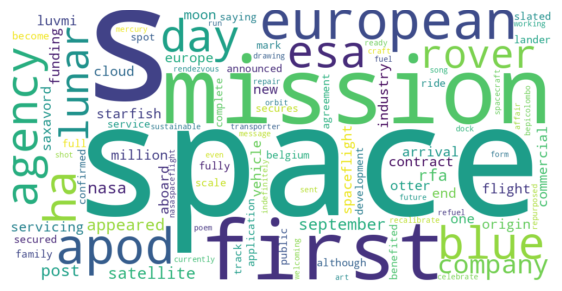

In [ ]:
text = ' '.join(df['prepro'].dropna().astype(str))

wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=100).generate(text)

plt.figure(figsize=(7, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
df[['id', 'title', 'text', 'prepro']].to_csv('spaceflight_preprocessed.csv', index=False)